## Results at a Glance

**One macro forecast, carried through to the three decisions it actually drives: rate positioning, policy anticipation, and credit provisioning.**

This project is organized around three risks that Australian banks are required to manage:

- The first is **interest rate risk**: if a bank misjudges how much prices will rise, the interest rates it has already locked in on loans and deposits stop matching what’s actually happening in the economy (Australian Prudential Regulation Authority [APRA], 2024). 
- The second is **policy risk**: guessing wrong about whether the Reserve Bank of Australia (RBA) will raise, hold, or cut its interest rate next and being caught off guard by the move. 
- The third is **credit risk**: when unemployment rises after an economic downturn, more borrowers fall behind on loan repayments, so underestimating how much unemployment will rise means underestimating those losses too—the exact relationship modelled in the RBA’s own bank stress-testing research (Garvin et al., 2022).

This project builds one inflation forecast (trimmed-mean CPI) and carries it through all three risk analysis. It forecasts inflation and checks it against the RBA’s own published forecast, using three different methods (SARIMA, Elastic Net, and an Ensemble that blends them). It builds a model that explains which economic factors are actually driving that forecast and simulates what would happen if one of them shifted unexpectedly (SVAR + Scenario Engine). It builds a tool that predicts the RBA’s next interest-rate decision from the same economic data (RBA Policy Classifier). And, separately, it estimates how much a bank like NAB could lose on its mortgage and personal loans if unemployment rises, using NAB’s own publicly disclosed loan and default figures (Credit Stress).

Every chart below is read directly from the same pinned reports/tableau/*.csv exports built for this project’s Tableau dashboard — no numbers are pasted in by hand.

```{admonition} What this page is, and isn't
:class: important
This is a methodology demonstration built on real, cited bank disclosures and a
peer-reviewed sensitivity paper not a production system, and not validated against
outcomes NAB itself hasn't already disclosed. The value being demonstrated is the pipeline
and the rigor (benchmarking against a real baseline, stating coverage gaps instead of
hiding them, correctly labelling illustrative outputs as illustrative), not a claim that
any single number is decision-ready.
```

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, MUTED = "#5b6f8f", "#9aa79f"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

TABLEAU = PROJECT_ROOT / "reports/tableau"
print(f"Reading pinned dashboard exports from {TABLEAU.relative_to(PROJECT_ROOT)}/")

Reading pinned dashboard exports from reports/tableau/


### Front 1 — mispriced rate risk

**Built:** three CPI forecasting families: SARIMA (univariate baseline), Elastic Net
(regularized, macro-feature-driven), and their Ensemble for both headline and
trimmed-mean CPI forecast, benchmarked against seasonal-naive and the RBA's own published forecast
(the RBA benchmark is NSA-only and evaluated separately in [§5 Evaluation](05_evaluation), not shown in the
SA-basis chart below).

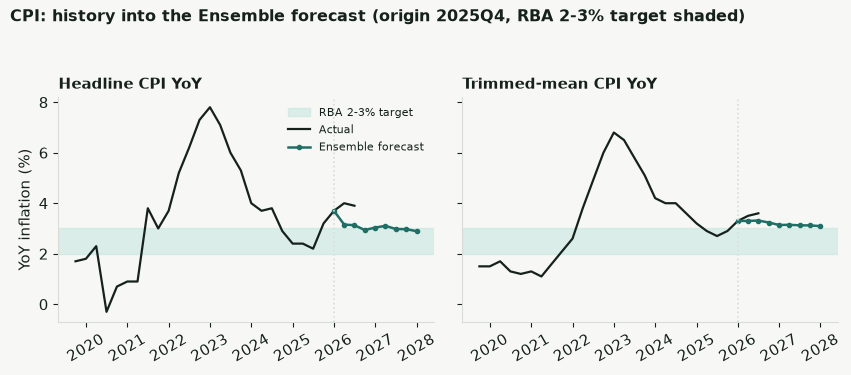

In [2]:
hist = pd.read_csv(TABLEAU / "historical_indicators.csv")
fc = pd.read_csv(TABLEAU / "forecast.csv")
fc_ens = fc[fc["model_family"] == "ensemble"].copy()
origin = fc_ens["forecast_origin"].iloc[0]

panels = [
    ("cpi_yoy", "Headline", "Headline CPI YoY"),
    ("trimmed_mean_cpi_yoy", "Trimmed mean", "Trimmed-mean CPI YoY"),
]

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8), sharey=True)
for ax, (variable, target_label, title) in zip(axes, panels):
    h = hist[hist["variable"] == variable].sort_values("quarter").tail(28).copy()
    h["quarter_date"] = pd.PeriodIndex(h["quarter"], freq="Q").to_timestamp(how="end")
    f = fc_ens[fc_ens["target"] == target_label].sort_values("horizon").copy()
    f["quarter_date"] = pd.PeriodIndex(f["quarter"], freq="Q").to_timestamp(how="end")

    origin_row = h[h["quarter"] == origin].iloc[0]
    ax.axhspan(2, 3, color=ACCENT_SOFT, alpha=0.5, zorder=0, label="RBA 2-3% target")
    ax.plot(h["quarter_date"], h["value"], color=INK, linewidth=1.6, label="Actual")
    fx = pd.concat([pd.Series([origin_row["quarter_date"]]), f["quarter_date"]], ignore_index=True)
    fy = pd.concat([pd.Series([origin_row["value"]]), f["forecast"]], ignore_index=True)
    ax.plot(fx, fy, color=ACCENT, linewidth=1.8, marker="o", markersize=3, label="Ensemble forecast")
    ax.axvline(origin_row["quarter_date"], color=GRID, linewidth=1.2, linestyle=":")
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False)

axes[0].set_ylabel("YoY inflation (%)")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
fig.suptitle(f"CPI: history into the Ensemble forecast (origin {origin}, RBA 2-3% target shaded)",
             x=0.01, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

```{admonition} Note
:class: note
Actuals continue past the forecast origin as new ABS releases land; this will be used to see how the forecast is tracking, not used to retrain the pinned model.
```

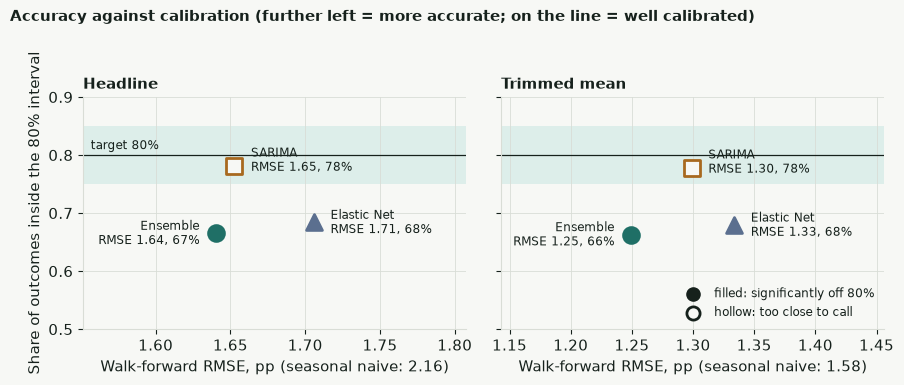

In [3]:
mc = pd.read_csv(TABLEAU / "model_comparison.csv")
cov = pd.read_csv(TABLEAU / "model_interval_coverage.csv")
summary = mc.merge(cov[["target", "model", "empirical_coverage", "significantly_miscalibrated"]],
                   on=["target", "model"], how="left")

names = {"sarima": "SARIMA", "elastic_net": "Elastic Net", "ensemble": "Ensemble"}
style = {"sarima": (HIGHLIGHT, "s"), "elastic_net": (BLUE, "^"), "ensemble": (ACCENT, "o")}
label_offset = {"sarima": (12, 4, "left"), "elastic_net": (12, 0, "left"), "ensemble": (-12, 0, "right")}

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.9), sharey=True)
for ax, target in zip(axes, ["Headline", "Trimmed mean"]):
    sub = summary[summary["target"] == target]
    naive = sub[sub["model"] == "seasonal_naive"]["rmse"].iloc[0]
    fitted = sub[sub["model"] != "seasonal_naive"]
    ax.axhspan(0.75, 0.85, color=ACCENT_SOFT, alpha=0.45, linewidth=0)
    ax.axhline(0.8, color=INK, linewidth=0.9)
    for _, r in fitted.iterrows():
        color, marker = style[r["model"]]
        off = bool(r["significantly_miscalibrated"])
        ax.scatter(r["rmse"], r["empirical_coverage"], s=130, marker=marker, color=color if off else PAPER,
                   edgecolor=color, linewidth=2.0, zorder=3)
        dx, dy, ha = label_offset[r["model"]]
        ax.annotate(f"{names[r['model']]}\nRMSE {r['rmse']:.2f}, {r['empirical_coverage'] * 100:.0f}%",
                    (r["rmse"], r["empirical_coverage"]), xytext=(dx, dy), textcoords="offset points",
                    ha=ha, va="center", fontsize=8.5)
    span = fitted["rmse"].max() - fitted["rmse"].min()
    ax.set_xlim(fitted["rmse"].min() - 0.9 * span - 0.03, fitted["rmse"].max() + 1.1 * span + 0.03)
    ax.set_title(target, loc="left", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"Walk-forward RMSE, pp (seasonal naive: {naive:.2f})")
    ax.set_ylim(0.5, 0.9)
axes[0].set_ylabel("Share of outcomes inside the 80% interval")
axes[0].text(0.02, 0.805, "target 80%", transform=axes[0].get_yaxis_transform(), fontsize=8.3, va="bottom")
axes[1].scatter([], [], s=90, color=INK, label="filled: significantly off 80%")
axes[1].scatter([], [], s=90, facecolor=PAPER, edgecolor=INK, linewidth=2.0, label="hollow: too close to call")
axes[1].legend(frameon=False, fontsize=8.3, loc="lower right")
fig.suptitle("Accuracy against calibration (further left = more accurate; on the line = well calibrated)",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

**Limitation.** The Ensemble has the lowest RMSE on both targets, a real if modest
improvement from combining models, but interval coverage still falls short of the nominal 80%:
SARIMA comes close (about 78%) while Elastic Net and the Ensemble cover roughly two-thirds.
Coverage is weakest through the 2020–23 inflation surge, when forecast errors jumped several-fold;
the intervals are widened using only errors already observed, so they follow a shock rather than
anticipate it. An overconfident interval is the specific failure mode that would hurt a rate-risk
use case, so it's shown plainly above rather than only as a point forecast.

*How to read the markers:* a filled marker means coverage is statistically distinguishable from 80% (an exact binomial test at the 5% level over this many forecasts); a hollow marker means too close to call. SARIMA's 78% is below 80% but hollow, because a gap that small is within what chance alone would produce.

### Front 2 — mistimed RBA policy positioning

**Built:** seven readings of the same cut/hold/hike decision: a threshold baseline, two
Taylor-rule variants, ordered logit/probit, Frank-Hall ordinal XGBoost, and a majority-vote
ensemble.

Forecast origin 2025Q4 -> target 2026Q1: the reportable call is 'hike' (threshold).


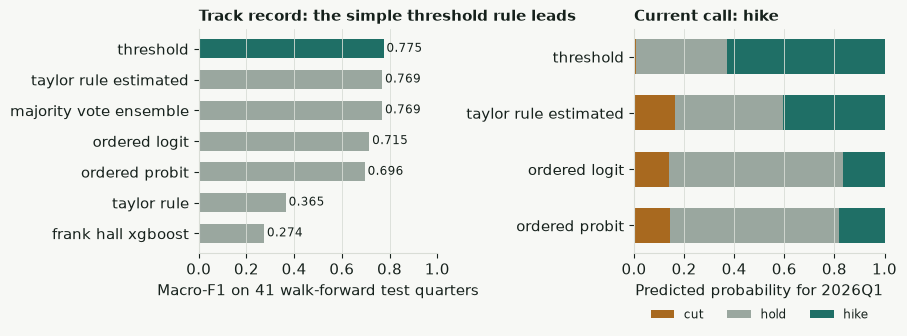

In [4]:
rba = pd.read_csv(TABLEAU / "rba_action.csv")
call = rba.iloc[0]
print(f"Forecast origin {call['forecast_origin']} -> target {call['target_quarter']}: "
      f"the reportable call is '{call['reportable_action']}' ({call['reportable_model']}).")

lines = (PROJECT_ROOT / "reports/rba_classifier_evaluation.md").read_text().splitlines()
start = next(i for i, l in enumerate(lines) if l.startswith("| model") and "macro_f1" in l)
rows = []
for l in lines[start:]:
    if not l.startswith("|"):
        break
    rows.append(l)
header = [c.strip() for c in rows[0].strip("|").split("|")]
data = [[c.strip() for c in r.strip("|").split("|")] for r in rows[2:]]
macro_f1 = (pd.DataFrame(data, columns=header).astype({"macro_f1": float, "accuracy": float, "n": int})
            .sort_values("macro_f1").reset_index(drop=True))
probs = rba.dropna(subset=["p_cut"]).set_index("model")[["p_cut", "p_hold", "p_hike"]].iloc[::-1]

fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.6), gridspec_kw={"width_ratios": [1, 1.05]})
colors = [ACCENT if m == call["reportable_model"] else MUTED for m in macro_f1["model"]]
a.barh(macro_f1["model"].str.replace("_", " "), macro_f1["macro_f1"], color=colors, height=0.62)
for y, v in enumerate(macro_f1["macro_f1"]):
    a.text(v + 0.012, y, f"{v:.3f}", va="center", fontsize=8.5)
a.set_xlim(0, 1)
a.set_xlabel("Macro-F1 on 41 walk-forward test quarters")
a.set_title("Track record: the simple threshold rule leads", loc="left", fontsize=10.5, fontweight="bold")
a.grid(axis="y", visible=False)

b.barh(probs.index.str.replace("_", " "), probs["p_cut"], color=HIGHLIGHT, height=0.62, label="cut")
b.barh(probs.index.str.replace("_", " "), probs["p_hold"], left=probs["p_cut"], color=MUTED, height=0.62, label="hold")
b.barh(probs.index.str.replace("_", " "), probs["p_hike"], left=probs["p_cut"] + probs["p_hold"], color=ACCENT,
       height=0.62, label="hike")
b.set_xlim(0, 1)
b.set_xlabel(f"Predicted probability for {call['target_quarter']}")
b.set_title(f"Current call: {call['reportable_action']}", loc="left", fontsize=10.5, fontweight="bold")
b.legend(frameon=False, ncol=3, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.2))
b.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**Limitation.** The threshold baseline is the reportable model, but its lead
over ordered logit/probit and the majority-vote ensemble is not statistically significant
(paired-bootstrap 95% confidence intervals cross zero). The honest claim is "a simple,
transparent baseline holds its own against more complex classifiers," not "we built a
superior RBA-prediction model," and it's a comparison exercise on historical decisions, not
a live validated track record.

### Front 3 — understated credit losses

**Built:** an illustrative 12-month AASB 9 expected credit loss (ECL), stressing NAB's own
disclosed probability of default (Pillar 3, Table CR6) with unemployment-sensitivity
coefficients from a published RBA research paper, using NAB's own disclosed loss-given-default (LGD) and exposure-at-default (EAD) plus an RBA-sourced discount rate, blended across
downside/base/upside scenarios at NAB's own disclosed probability weights.

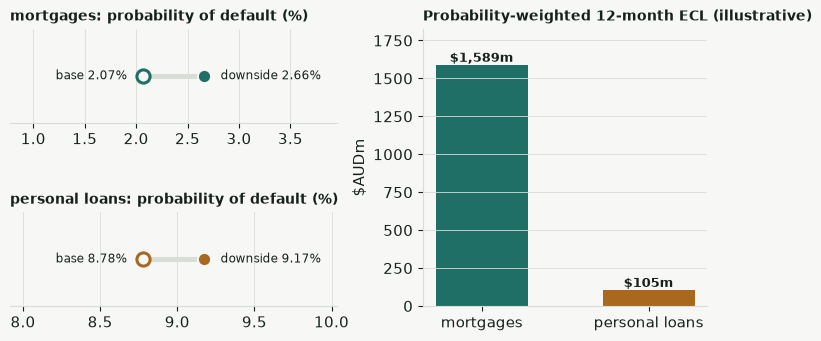

In [5]:
credit = pd.read_csv(TABLEAU / "credit_stress.csv")
segments = [("mortgages", ACCENT), ("personal_loans", HIGHLIGHT)]

fig = plt.figure(figsize=(9.0, 3.6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.15, 1], hspace=0.95, wspace=0.28)
for row, (seg, color) in enumerate(segments):
    a = fig.add_subplot(gs[row, 0])
    down = credit[(credit["segment"] == seg) & (credit["scenario"] == "downside")].iloc[0]
    lo, hi = down["pd_base"] * 100, down["pd_stressed"] * 100
    a.plot([lo, hi], [0, 0], color=GRID, linewidth=3.5, zorder=1)
    a.scatter(lo, 0, s=90, facecolor=PAPER, edgecolor=color, linewidth=2.2, zorder=3)
    a.scatter(hi, 0, s=90, color=color, edgecolor=PAPER, linewidth=1.4, zorder=3)
    a.annotate(f"base {lo:.2f}%", (lo, 0), xytext=(-12, 0), textcoords="offset points", ha="right", va="center", fontsize=8.8)
    a.annotate(f"downside {hi:.2f}%", (hi, 0), xytext=(12, 0), textcoords="offset points", ha="left", va="center", fontsize=8.8)
    pad = (hi - lo) * 2.2
    a.set_xlim(lo - pad, hi + pad)
    a.set_ylim(-1, 1)
    a.set_yticks([])
    a.set_title(f"{seg.replace('_', ' ')}: probability of default (%)", loc="left", fontsize=10, fontweight="bold")
    a.grid(axis="y", visible=False)
    a.spines["left"].set_visible(False)

b = fig.add_subplot(gs[:, 1])
weighted = credit.drop_duplicates("segment").set_index("segment")["ecl_aud_m_12m_probability_weighted"]
b.bar([s.replace("_", " ") for s, _ in segments], [weighted[s] for s, _ in segments], color=[c for _, c in segments], width=0.55)
for x, (s, _) in enumerate(segments):
    b.text(x, weighted[s], f"${weighted[s]:,.0f}m", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
b.set_ylim(0, weighted.max() * 1.15)
b.set_ylabel("$AUDm")
b.set_title("Probability-weighted 12-month ECL (illustrative)", loc="left", fontsize=10, fontweight="bold")
b.grid(axis="x", visible=False)
plt.show()

**Limitation, the one to be most careful not to overstate:** this figure is **not**
comparable to NAB's real provision, and is larger than it in an explainable, not alarming,
way. It's a 12-month, Stage-1-only calculation with no staging logic, applied to the full
exposure rather than a genuine Stage-1 subset — structurally inflated versus a real
provision by construction. NAB's real Stage 1 provision was \$646 million of a \$6,165
million Group total (roughly 10.5%); this project's illustrative mortgages ECL above is
larger than that *and* larger than NAB's real total (all-stage) Housing provision of \$1.296
billion. It is not a lower bound on, or any kind of estimate of, NAB's real ECL, and it is
not for actual credit or regulatory decisions.

### The connecting piece — SVAR and the Scenario Engine

SVAR supplies the unemployment scenario Credit Stress consumes directly, and feeds the
Scenario Engine's "what if" shocks to CPI. Three of the four shock channels are cleanly
signed (unemployment up → CPI down, commodity growth up → CPI up, inflation expectations
up → CPI up); the cash-rate channel shows a well-documented "price puzzle" artifact of this
model class, not a bug. But both underlying VAR systems still fail their own multivariate
residual whiteness and normality diagnostics, so everything downstream of SVAR — including
every Scenario Engine output — is illustrative, not causal.

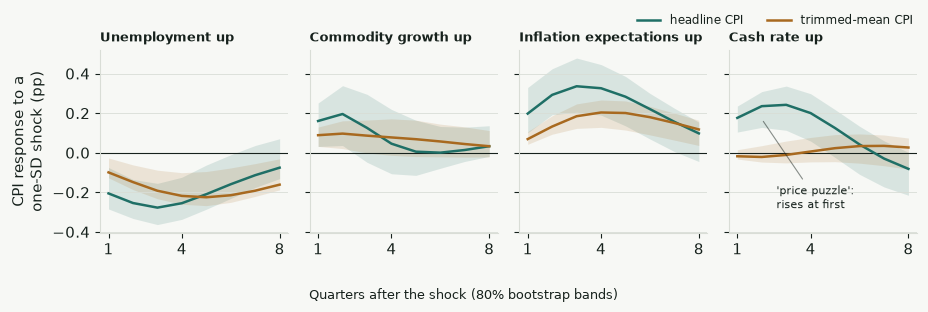

In [6]:
irf = pd.read_csv(TABLEAU / "svar_irf.csv")
irf = irf[irf["response"] == irf["target"]]
shocks = [("unemployment_rate", "Unemployment up"), ("commodity_growth", "Commodity growth up"),
          ("inflation_expectations_business", "Inflation expectations up"), ("cash_rate", "Cash rate up")]
systems = [("System A", "headline CPI", ACCENT), ("System B", "trimmed-mean CPI", HIGHLIGHT)]

fig, axes = plt.subplots(1, 4, figsize=(9.4, 2.9), sharex=True, sharey=True)
for ax, (shock, title) in zip(axes, shocks):
    ax.axhline(0, color=INK, linewidth=0.8)
    for system, label, color in systems:
        s = irf[(irf["system"] == system) & (irf["shock"] == shock)].sort_values("horizon")
        ax.fill_between(s["horizon"], s["lower"], s["upper"], color=color, alpha=0.14, linewidth=0)
        ax.plot(s["horizon"], s["irf"], color=color, linewidth=1.8, label=label)
    ax.set_title(title, loc="left", fontsize=9.3, fontweight="bold")
    ax.set_xticks([1, 4, 8])
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("CPI response to a\none-SD shock (pp)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8.5, loc="upper right", ncol=2, bbox_to_anchor=(0.99, 1.04))
axes[3].annotate("'price puzzle':\nrises at first", (2, 0.17), xytext=(2.6, -0.28), fontsize=8, ha="left",
                 arrowprops=dict(arrowstyle="-", color=INK, alpha=0.5, lw=0.8))
fig.supxlabel("Quarters after the shock (80% bootstrap bands)", fontsize=9)
fig.tight_layout()
plt.show()

### Grounded in real disclosures, not invented assumptions

Every business figure above is sourced, not assumed: NAB's own FY2025 disclosures (Pillar
3 and Annual Report) supply the default, loss, exposure, and scenario-weighting inputs, and
a peer-reviewed Reserve Bank of Australia research paper supplies the unemployment
sensitivity used to stress them.

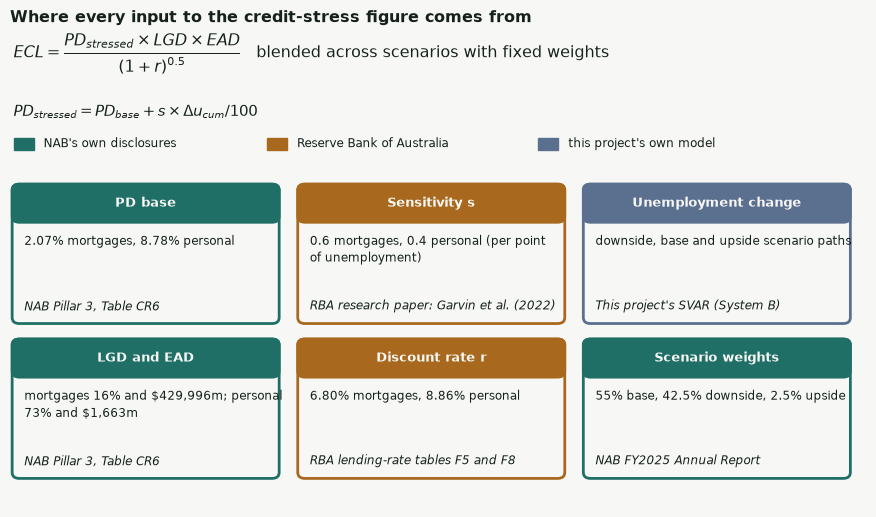

In [7]:
import textwrap
from matplotlib.patches import FancyBboxPatch

credit = pd.read_csv(TABLEAU / "credit_stress.csv")
seg = credit.drop_duplicates("segment").set_index("segment")
m, p = seg.loc["mortgages"], seg.loc["personal_loans"]
w = credit[credit["segment"] == "mortgages"].set_index("scenario")["probability_weight"]

NAB, RBA, SVAR = ACCENT, HIGHLIGHT, BLUE
inputs = [   # (term, values, source, colour)
    ("PD base", f"{m['pd_base'] * 100:.2f}% mortgages, {p['pd_base'] * 100:.2f}% personal", "NAB Pillar 3, Table CR6", NAB),
    ("Sensitivity s", f"{m['ur_sensitivity']:.1f} mortgages, {p['ur_sensitivity']:.1f} personal (per point of unemployment)",
     "RBA research paper: Garvin et al. (2022)", RBA),
    ("Unemployment change", "downside, base and upside scenario paths", "This project's SVAR (System B)", SVAR),
    ("LGD and EAD", f"mortgages {m['lgd'] * 100:.0f}% and ${m['ead_aud_m']:,.0f}m; personal {p['lgd'] * 100:.0f}% and ${p['ead_aud_m']:,.0f}m",
     "NAB Pillar 3, Table CR6", NAB),
    ("Discount rate r", f"{m['discount_rate'] * 100:.2f}% mortgages, {p['discount_rate'] * 100:.2f}% personal",
     "RBA lending-rate tables F5 and F8", RBA),
    ("Scenario weights", f"{w['base'] * 100:g}% base, {w['downside'] * 100:g}% downside, {w['upside'] * 100:g}% upside",
     "NAB FY2025 Annual Report", NAB),
]
fig, ax = plt.subplots(figsize=(9.2, 5.3))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis("off")
ax.text(0.05, 7.95, r"$ECL = \dfrac{PD_{stressed} \times LGD \times EAD}{(1+r)^{0.5}}$   blended across scenarios with fixed weights",
        fontsize=11.5, va="top")
ax.text(0.05, 6.75, r"$PD_{stressed} = PD_{base} + s \times \Delta u_{cum} / 100$", fontsize=10.5, va="top")
for x, color, label in [(0.05, NAB, "NAB's own disclosures"), (3.6, RBA, "Reserve Bank of Australia"), (7.4, SVAR, "this project's own model")]:
    ax.add_patch(plt.Rectangle((x, 6.0), 0.28, 0.2, facecolor=color, edgecolor=color))
    ax.text(x + 0.42, 6.1, label, va="center", fontsize=8.8)
bw, bh, gx, gy = 3.7, 2.3, 0.3, 0.3
for i, (term, values, source, color) in enumerate(inputs):
    r, c = divmod(i, 3)
    x, y = 0.05 + c * (bw + gx), 5.4 - bh - r * (bh + gy) + 0.0
    y = 5.4 - (r + 1) * bh - r * gy
    ax.add_patch(FancyBboxPatch((x, y), bw, bh, boxstyle="round,pad=0.02,rounding_size=0.1", facecolor=PAPER,
                                edgecolor=color, linewidth=2.0))
    ax.add_patch(FancyBboxPatch((x, y + bh - 0.6), bw, 0.6, boxstyle="round,pad=0.02,rounding_size=0.1",
                                facecolor=color, edgecolor=color, linewidth=2.0))
    ax.text(x + bw / 2, y + bh - 0.3, term, ha="center", va="center", fontsize=9.5, fontweight="bold", color=PAPER)
    ax.text(x + 0.15, y + bh - 0.8, "\n".join(textwrap.wrap(values, 40)), ha="left", va="top", fontsize=8.6, linespacing=1.4)
    ax.text(x + 0.15, y + 0.15, "\n".join(textwrap.wrap(source, 42)), ha="left", va="bottom", fontsize=8.3,
            style="italic", linespacing=1.3)
ax.set_title("Where every input to the credit-stress figure comes from", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()

### Read on

The rest of this book walks through the full CRISP-DM pipeline behind these numbers, with
every equation followed by a plain-English explanation — starting with [Business Understanding](01_business_understanding). To jump straight to a
model: [SARIMA](04_modeling/41_sarima), [Elastic Net](04_modeling/42_elastic_net), and
[Ensemble](04_modeling/43_ensemble); [SVAR](04_modeling/44_svar) and the
[Scenario Engine](04_modeling/45_scenario_engine); the
[RBA Policy Classifier](04_modeling/46_rba_classifier); [Credit Stress](04_modeling/47_credit_stress).

### References

Australian Prudential Regulation Authority. (2024). *Prudential standard APS 117: Capital
adequacy — interest rate risk in the banking book* (Determination No. 5 of 2024).
https://www.legislation.gov.au/F2024L01182/latest/text

Garvin, N., Kurian, S., Major, M., & Norman, D. (2022). *Macrofinancial stress testing on
Australian banks* (Research Discussion Paper No. RDP 2022-03). Reserve Bank of Australia.
https://www.rba.gov.au/publications/rdp/2022/2022-03.html